# Lab 7/8: Event Horizon Telescope Data
**Names**: Leo Quintana, Marcos Marroquin

**Course:** Physics 434 - Data Analysis Lab  
**Objective:** In this lab we explore real Event Horizon Telescope interferometry data. Our goal is to understand the statistical differences between uncalibrated and calibrated visibilities, and to investigate methods for mapping raw visibility amplitudes to calibrated ones. We perform exploratory data analysis, apply formal statistical tests (Pearson/Spearman correlation, KS test), and train a simple neural network to learn the uncalibrated → calibrated amplitude transformation.

### Loading in the EHT dataset 
Here we use ehtim instead of the eats library recommend as it was much easier to work with, we take a look at the variable list and other important features of both dataset summary.

We transform the data into a pandas dataframe for easier plotting to compare the variable/metrics.

In [1]:
import sys
import ehtim as eh
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

Welcome to eht-imaging! v 1.2.10 



In [2]:
calibrated_file = 'SR1_M87_2017_101_lo_hops_netcal_StokesI.uvfits'
# Load uncalibrated data from uvfits file
obs_cal = eh.obsdata.load_uvfits(calibrated_file)
print(f"Source: {obs_cal.source}")
print(f"Observation frequency: {obs_cal.rf/1e9:.1f} GHz")
print(f"Observation time: {obs_cal.mjd} MJD")
print(f"Number of data points: {len(obs_cal.data)}")
print(f"Data columns: {list(obs_cal.data.dtype.names)}")

# load calibrated data from uvfits file
uncalibrated_file = 'EHT2017_3601_Stage1/hops_3601_M87+avg.uvfits'
obs_uncal = eh.obsdata.load_uvfits(uncalibrated_file)
print(f"Source: {obs_uncal.source}")
print(f"Observation frequency: {obs_uncal.rf/1e9:.1f} GHz")
print(f"Observation time: {obs_uncal.mjd} MJD")
print(f"Number of data points: {len(obs_uncal.data)}")
print(f"Data columns: {list(obs_uncal.data.dtype.names)}")

# Convert data to pandas DataFrame
cal_df = pd.DataFrame(obs_cal.data)
uncal_df = pd.DataFrame(obs_uncal.data)
 



Loading uvfits:  SR1_M87_2017_101_lo_hops_netcal_StokesI.uvfits
no IF in uvfits header!
POLREP_UVFITS: circ
Number of uvfits Correlation Products: 4
No NX table in uvfits!
Source: M87
Observation frequency: 227.1 GHz
Observation time: 57854 MJD
Number of data points: 7447
Data columns: ['time', 'tint', 't1', 't2', 'tau1', 'tau2', 'u', 'v', 'vis', 'qvis', 'uvis', 'vvis', 'sigma', 'qsigma', 'usigma', 'vsigma']
Loading uvfits:  EHT2017_3601_Stage1/hops_3601_M87+avg.uvfits
no IF in uvfits header!
POLREP_UVFITS: circ
Number of uvfits Correlation Products: 4
Source: M87
Observation frequency: 227.1 GHz
Observation time: 57854 MJD
Number of data points: 7646
Data columns: ['time', 'tint', 't1', 't2', 'tau1', 'tau2', 'u', 'v', 'vis', 'qvis', 'uvis', 'vvis', 'sigma', 'qsigma', 'usigma', 'vsigma']


## Exploratory Data Analysis
**We investigate the following:**
* Compare SNR distributions, visibility amplitude histograms, and UV coverage between datasets
* Examine visibility amplitudes vs baseline length to understand the spatial structure of M87
* Build matched observation pairs (same baseline, same time) for statistical comparison
* Apply formal statistical tests to characterize the uncalibrated → calibrated relationship
* Train a neural network to learn the amplitude transformation

### The next few plots are to visualize and compared the features of the Calibrated and Uncalibrated data:
We aren't very interest in the exact comparison of features besides the one we will go in depth into later. These graphs along with understanding radio interferometry and our paper "EHT-HOPS Pipeline for Millimeter VLBI Data Reduction" allow us to deeply understand our dataset before looking more in depth on the visability amplitudes.

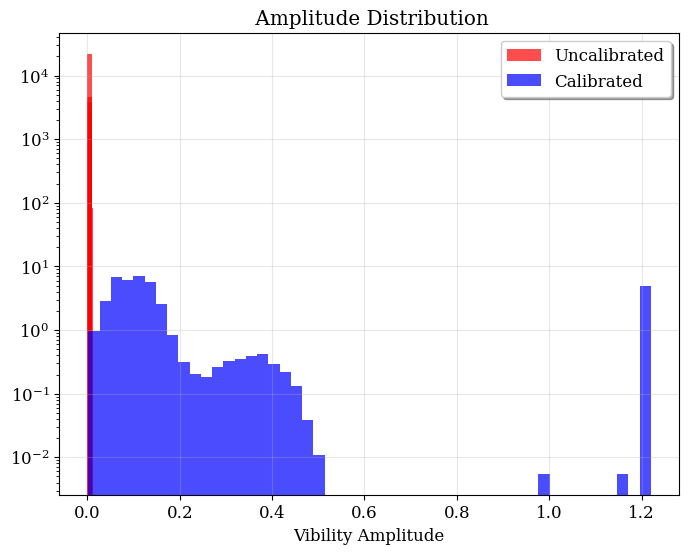

In [3]:
# calculate visibility amplitudes
uncal_amp = np.abs(uncal_df['vis']) 
cal_amp = np.abs(cal_df['vis'])

# plot histograms comparing visibility amplitudes
fig,ax = plt.subplots(figsize=(8,6))
ax.hist(uncal_amp, bins=50, alpha=0.7, density = True, label='Uncalibrated', color = 'red', width = .01)
ax.hist(cal_amp, bins=50, alpha=0.7, density = True, label = 'Calibrated', color ='blue' )
ax.set_yscale('log')
ax.set_title(' Amplitude Distribution')
ax.set_xlabel('Vibility Amplitude')
ax.grid(True, alpha=0.3)
ax.legend(shadow=True);

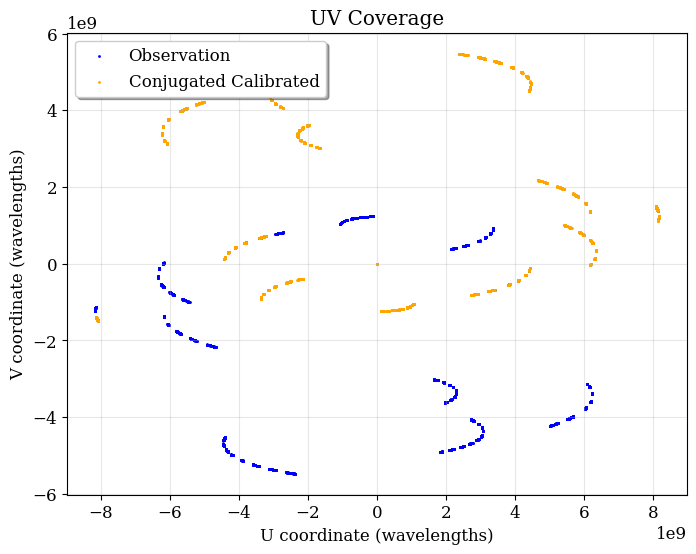

In [4]:
cal_v = cal_df['v']
cal_u = cal_df['u']

fig, ax = plt.subplots(figsize=(8,6))
ax.scatter(cal_u, cal_v, s=1, color='blue', label='Observation')
ax.scatter(-cal_u, -cal_v, s=1, color='orange', label='Conjugated Calibrated')
ax.set_title("UV Coverage")
ax.set_xlabel("U coordinate (wavelengths)")
ax.set_ylabel("V coordinate (wavelengths)")
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3)
ax.legend(shadow=True);


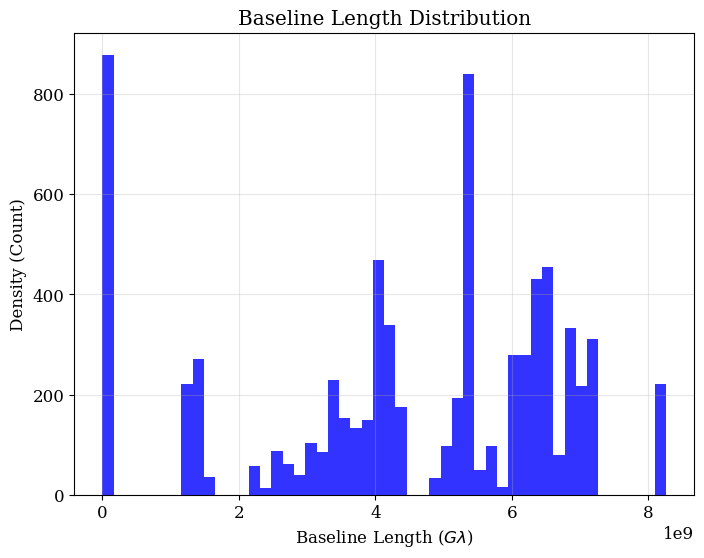

In [5]:
# calculate baseline lengths from antenna/dishes
baseline_lengths = np.sqrt(cal_u**2 + cal_v**2)

# plot histogram of baseline lengths
fig, ax = plt.subplots(figsize=(8,6))
ax.hist(baseline_lengths, bins =50, color='blue',alpha = 0.8)
ax.set_title("Baseline Length Distribution")
ax.set_xlabel(r'Baseline Length ($G\lambda$)')
ax.set_ylabel(r'Density (Count)')
ax.grid(True, alpha=0.3)

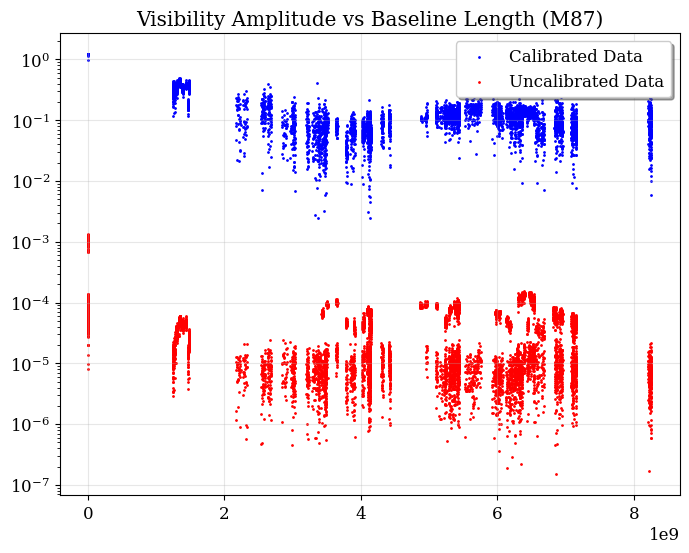

In [6]:
# find baseline lengths for uncalibrated data
uncal_v = uncal_df['v']
uncal_u = uncal_df['u']
uncal_baseline_lengths = np.sqrt(uncal_u**2 + uncal_v**2)

# plot visibility amplitude vs baseline length
fig, ax = plt.subplots(figsize=(8,6))
ax.scatter(baseline_lengths, cal_amp, s=1, color='blue', label='Calibrated Data')
ax.set_title("Visibility Amplitude vs Baseline Length (M87)")
ax.scatter(uncal_baseline_lengths, uncal_amp, s=1, color='red', label='Uncalibrated Data')
ax.set_yscale('log')
ax.grid(True, alpha=0.3)
ax.legend(loc='upper right',shadow=True);

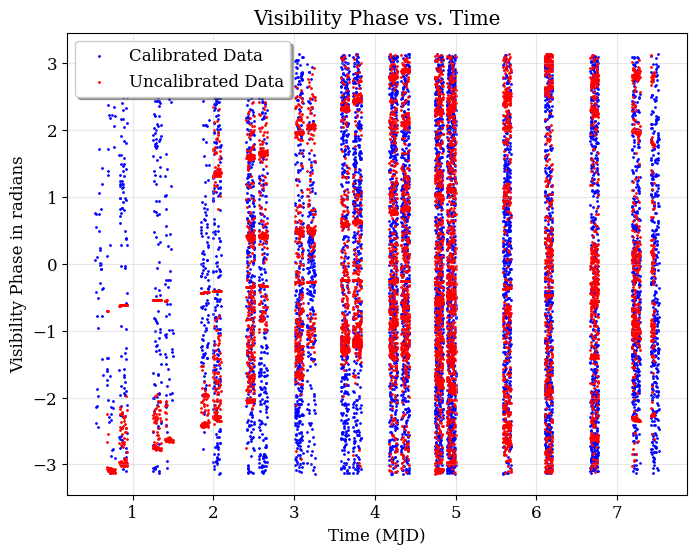

In [7]:

times_cal = obs_cal.data['time']  # in MJD
times_uncal = obs_uncal.data['time']  # in MJD
phases_cal = np.angle(obs_cal.data['vis'])  # in radians
phases_uncal = np.angle(obs_uncal.data['vis'])  # in radians

fig, ax = plt.subplots(figsize=(8,6))
ax.scatter(times_uncal, phases_uncal, s=1, color='blue', label='Calibrated Data')
ax.scatter(times_cal, phases_cal, s=1, color='red', label='Uncalibrated Data')
ax.set_title('Visibility Phase vs. Time')
ax.set_xlabel('Time (MJD)')
ax.set_ylabel('Visibility Phase in radians')
ax.grid(True, alpha=0.3)
ax.legend(shadow = True);

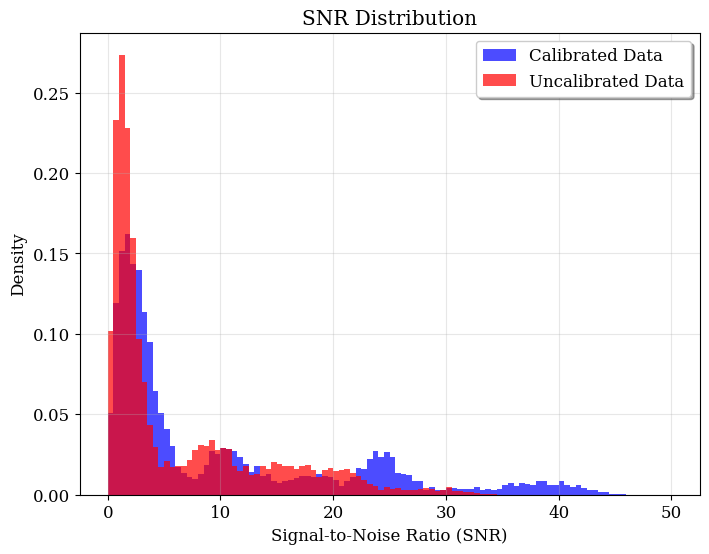

In [8]:
snr_cal = np.abs(obs_cal.data['vis']) / obs_cal.data['sigma']  # SNR for calibrated data
snr_uncal = np.abs(obs_uncal.data['vis']) / obs_uncal.data['sigma']  # SNR for uncalibrated data
fig, ax = plt.subplots(figsize=(8,6))
ax.hist(snr_cal, bins=100, color='blue', alpha=0.7, label='Calibrated Data', density=True, range =(0,50)) 
ax.hist(snr_uncal, bins=100, color='red', alpha=0.7, label='Uncalibrated Data', density=True, range =(0,50))
ax.set_title('SNR Distribution')
ax.set_xlabel('Signal-to-Noise Ratio (SNR)')
ax.set_ylabel('Density')
ax.grid(True, alpha=0.3)
ax.legend(shadow=True);

We see calibrated data has much higher SNR and visibility amplitude with less valid points

### Side-by-Side Amplitude Distributions: Calibrated vs Uncalibrated
The visual separation here motivates the statistical tests in the next section — the KS test will put a number on exactly how different these distributions are.

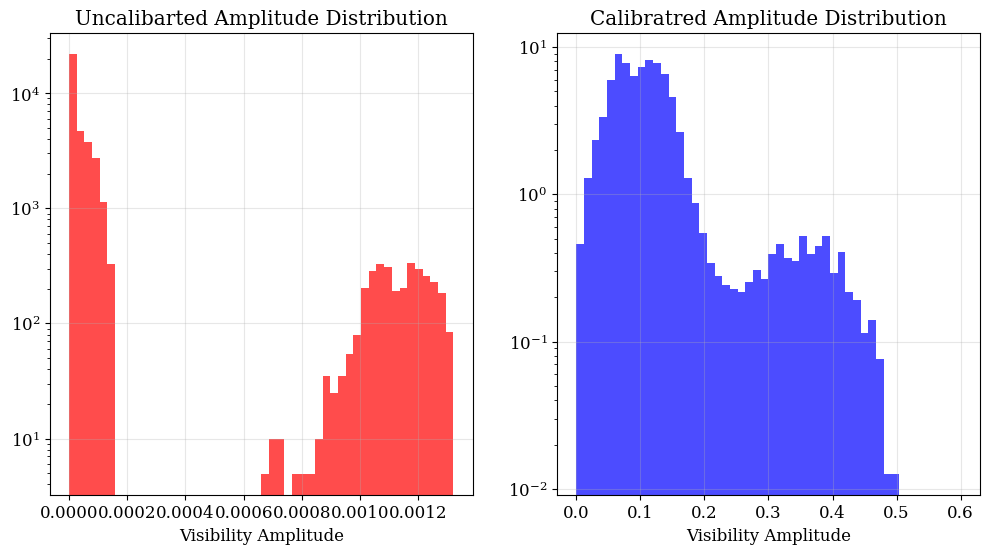

In [9]:
# Split the visbitility amplitudes into tow different plots calibrated and uncalibrated
fig,ax = plt.subplots(1,2, figsize=(12,6))
ax[0].hist(uncal_amp, bins=50, alpha=0.7, density = True, label='Uncalibrated', color = 'red')
ax[0].set_yscale('log')
ax[0].set_xlabel('Visibility Amplitude')
ax[0].set_title('Uncalibarted Amplitude Distribution')
ax[0].grid(True, alpha=0.3)

ax[1].hist(cal_amp, bins=50, alpha=0.7, range = (0,0.6), density = True, label = 'Calibrated', color ='blue' )
ax[1].set_yscale('log')
ax[1].set_title('Calibratred Amplitude Distribution')
ax[1].set_xlabel('Visibility Amplitude')
ax[1].grid(True, alpha=0.3)

 

## Statistical Analysis: Understanding the Uncalibrated → Calibrated Relationship

Before building any model, we need to understand whether a learnable relationship even exists. Two key questions:

1. **Are they correlated?** If uncalibrated amplitude carries no information about calibrated amplitude, no model can predict one from the other.
2. **Are the distributions statistically different?** The KS test gives a formal answer instead of just eyeballing histograms.

To do this properly we need **matched pairs** — the same physical measurement (same baseline, same time) with both its uncalibrated and calibrated value. We build that dataset here. It will also be reused for the neural network later.

In [ ]:
from scipy.stats import pearsonr, spearmanr, ks_2samp, linregress

df_cal   = pd.DataFrame(obs_cal.data)
df_uncal = pd.DataFrame(obs_uncal.data)

# Merge on antenna pair (t1, t2) AND observation time.
# 'inner' join = only keep rows where a match exists in BOTH datasets.
# This gives us side-by-side (uncal, cal) values for the same measurement.
merged = pd.merge(df_cal, df_uncal, on=['t1', 't2', 'time'],
                  suffixes=('_cal', '_uncal'), how='inner')

# Drop columns duplicated across cal/uncal after the merge
merged = merged.drop(columns=['tau1_cal', 'tau2_cal', 'tau1_uncal', 'tau2_uncal',
                                'u_uncal', 'v_uncal'])

# Compute amplitude = |complex visibility| and SNR for each matched pair.
# np.abs on a complex number gives its magnitude: sqrt(real² + imag²)
merged['baseline_length'] = np.sqrt(merged['u_cal']**2 + merged['v_cal']**2)
merged['amp_cal'] = np.abs(merged['vis_cal'].values)
merged['amp_uncal'] = np.abs(merged['vis_uncal'].values)
merged['snr_cal'] = merged['amp_cal']   / merged['sigma_cal'].values
merged['snr_uncal'] = merged['amp_uncal'] / merged['sigma_uncal'].values

print(f"Matched observation pairs : {len(merged)}")
print(f"Unique baseline pairs : {merged.groupby(['t1','t2']).ngroups}")
merged[['t1','t2','amp_uncal','amp_cal','snr_uncal','snr_cal','baseline_length']].head()

Matched observation pairs : 7446
Unique baseline pairs     : 21


,t1,t2,amp_uncal,amp_cal,snr_uncal,snr_cal,baseline_length
0,AA,PV,0.000124,0.155493,26.949048,40.478674,6.297614e+09
1,AA,PV,0.000141,0.166642,30.866233,42.857604,6.298452e+09
2,AA,PV,0.000113,0.154420,24.630019,39.430662,6.299333e+09
3,AA,PV,0.000116,0.159381,24.666971,38.719074,6.300203e+09
4,AA,PV,0.000069,0.152172,15.972271,37.092763,6.301020e+09


### Pearson and Spearman Correlation

We compute two types of correlation between uncalibrated and calibrated amplitudes:

- **Pearson r**: measures the *linear* relationship. r = 1 means a perfect straight line, r = 0 means no linear relationship.
- **Spearman r**: measures the *rank-order* relationship. It asks "does cal tend to be higher when uncal is higher?" without assuming the relationship is a straight line. More robust to outliers.

The **p-value** tells us whether the result could be due to random chance (p < 0.05 = statistically significant).

In [11]:
# pearsonr and spearmanr each return (correlation_coefficient, p_value)
pearson_r,  pearson_p  = pearsonr(merged['amp_uncal'],  merged['amp_cal'])
spearman_r, spearman_p = spearmanr(merged['amp_uncal'], merged['amp_cal'])

pearson_snr_r,  pearson_snr_p  = pearsonr(merged['snr_uncal'],  merged['snr_cal'])
spearman_snr_r, spearman_snr_p = spearmanr(merged['snr_uncal'], merged['snr_cal'])

print("=== Visibility Amplitude Correlation ===")
print(f"  Pearson  r = {pearson_r:.4f}   (p = {pearson_p:.2e})")
print(f"  Spearman r = {spearman_r:.4f}   (p = {spearman_p:.2e})")
print()
print("=== SNR Correlation ===")
print(f"  Pearson  r = {pearson_snr_r:.4f}   (p = {pearson_snr_p:.2e})")
print(f"  Spearman r = {spearman_snr_r:.4f}   (p = {spearman_snr_p:.2e})")

=== Visibility Amplitude Correlation ===
  Pearson  r = 0.8308   (p = 0.00e+00)
  Spearman r = 0.3654   (p = 5.12e-234)

=== SNR Correlation ===
  Pearson  r = 0.9942   (p = 0.00e+00)
  Spearman r = 0.8549   (p = 0.00e+00)


### Kolmogorov-Smirnov (KS) Test

The KS test formally answers: *"Could these two samples have come from the same distribution?"*

- **KS statistic**: the maximum vertical distance between the two cumulative distribution functions (CDFs). Ranges from 0 to 1. Larger = more different.
- **p-value**: near 0 means we can confidently say the distributions are NOT the same.

This replaces the visual histogram comparison from the EDA section with a number we can actually cite.

In [12]:
ks_stat, ks_p = ks_2samp(merged['amp_uncal'], merged['amp_cal'])

print("=== KS Test: Uncalibrated vs Calibrated Amplitudes ===")
print(f"  KS statistic : {ks_stat:.4f}  (max CDF difference between the two distributions)")
print(f"  p-value      : {ks_p:.2e}")
print()
if ks_p < 0.05:
    print("Result: The distributions ARE statistically different (p < 0.05).")
    print("Calibration substantially changes the amplitude distribution — not just a simple rescaling.")
else:
    print("Result: No significant difference detected (p >= 0.05).")

=== KS Test: Uncalibrated vs Calibrated Amplitudes ===
  KS statistic : 1.0000  (max CDF difference between the two distributions)
  p-value      : 0.00e+00

Result: The distributions ARE statistically different (p < 0.05).
Calibration substantially changes the amplitude distribution — not just a simple rescaling.


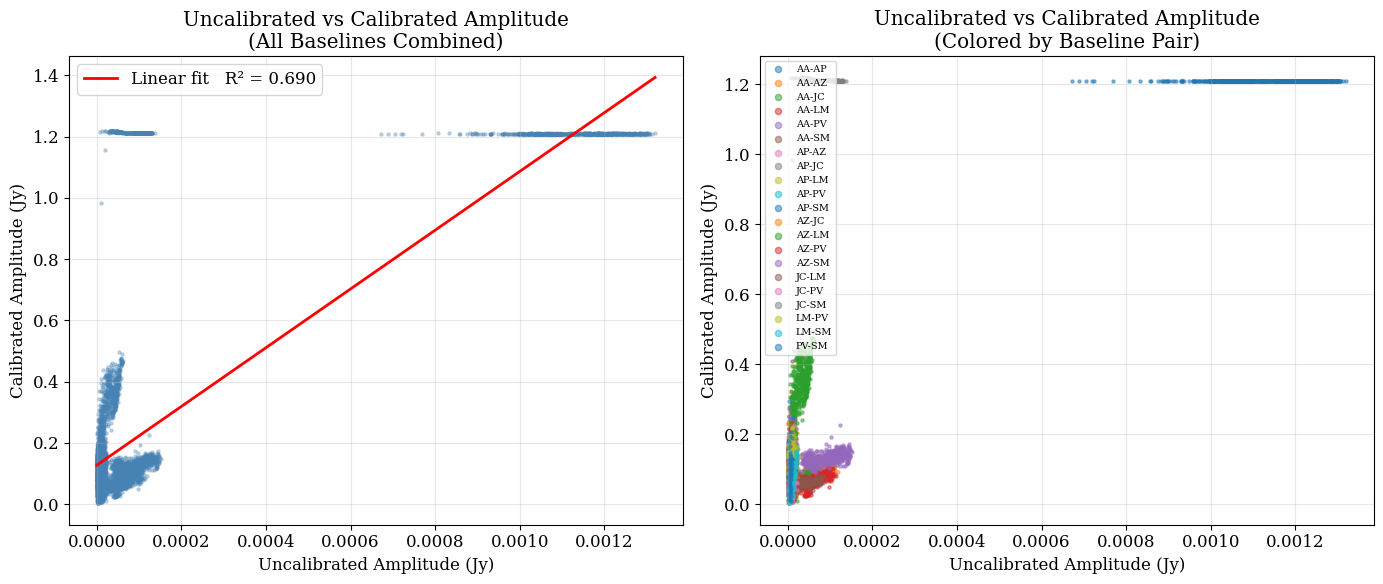

Linear fit : cal_amp ≈ 959.5 × uncal_amp + 0.1272
R²         : 0.6903  →  linear model explains 69.0% of variance in cal amplitude


In [13]:
# Fit a simple linear regression: cal_amp = slope * uncal_amp + intercept
# linregress returns: slope, intercept, r (correlation), p-value, standard error
slope, intercept, r_value, p_value, std_err = linregress(merged['amp_uncal'], merged['amp_cal'])

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# --- Left: Overall scatter with linear fit ---
# This shows whether there is ANY linear relationship across all baselines combined
axes[0].scatter(merged['amp_uncal'], merged['amp_cal'], s=5, alpha=0.3, color='steelblue')
x_line = np.linspace(merged['amp_uncal'].min(), merged['amp_uncal'].max(), 200)
axes[0].plot(x_line, slope * x_line + intercept, color='red', lw=2,
             label=f'Linear fit   R² = {r_value**2:.3f}')
axes[0].set_xlabel('Uncalibrated Amplitude (Jy)')
axes[0].set_ylabel('Calibrated Amplitude (Jy)')
axes[0].set_title('Uncalibrated vs Calibrated Amplitude\n(All Baselines Combined)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# --- Right: Same scatter, colored by baseline pair ---
# Each color = one antenna pair.
# If each color forms a distinct cluster, it means the gain correction is
# DIFFERENT per antenna pair — and baseline identity will matter as a model feature.
for name, group in merged.groupby(['t1', 't2']):
    axes[1].scatter(group['amp_uncal'], group['amp_cal'],
                    s=5, alpha=0.5, label=f'{name[0]}-{name[1]}')
axes[1].set_xlabel('Uncalibrated Amplitude (Jy)')
axes[1].set_ylabel('Calibrated Amplitude (Jy)')
axes[1].set_title('Uncalibrated vs Calibrated Amplitude\n(Colored by Baseline Pair)')
axes[1].legend(loc='upper left', fontsize=7, markerscale=2)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Linear fit : cal_amp ≈ {slope:.1f} × uncal_amp + {intercept:.4f}")
print(f"R²         : {r_value**2:.4f}  →  linear model explains {r_value**2*100:.1f}% of variance in cal amplitude")

### What the Statistical Analysis Tells Us

- **Correlation results**: High Spearman r means uncalibrated amplitude reliably ranks alongside calibrated amplitude — there's genuine signal for a model to learn from. Low Pearson r (with high Spearman r) would mean the relationship exists but isn't a straight line.

- **KS Test**: The large KS statistic confirms that calibration isn't just a simple rescaling — it fundamentally reshapes the amplitude distribution. A naive "multiply by a constant" approach won't work.

- **Scatter colored by baseline** (most important plot): If each antenna pair forms a distinct cluster with its own slope, the gain correction applied during calibration is **different per baseline pair**. This means any model we build needs to know *which* baseline it's predicting for — not just the raw amplitude value.

## Statistical Analysis Summary

- Uncalibrated and calibrated amplitudes **are correlated** — a model has genuine signal to learn from.
- The KS test confirms the distributions are **statistically distinct** — calibration is doing real work, not just rescaling.
- The per-baseline scatter reveals **baseline-dependent gain structure** — any model needs to know which antenna pair it's working with, not just the raw amplitude value. This will directly inform our feature choices in the neural network.

### We take a look at how diverse the data is in terms of baseline pairs which we will utilize in the train-test splitting:

### Neural Network: Predicting Calibrated Amplitude from Uncalibrated Data

The `merged` dataframe of matched observation pairs was already built in the statistical analysis section above. We now use it to train a neural network to predict `amp_cal` from uncalibrated features.

We'll also apply the insight from the scatter plot: since each baseline pair has its own gain structure, we split train/test by baseline pair rather than randomly — ensuring the model is tested on data from baselines it actually trained on.

In [14]:
# merged was already created in the statistical analysis section.
# Quick reminder of what it contains before we start building the model.
print(f"Total matched pairs : {len(merged)}")
print(f"Baseline pairs      : {merged.groupby(['t1','t2']).ngroups}")
display(merged[['t1','t2','amp_uncal','amp_cal','snr_uncal','snr_cal','baseline_length']].head())

Total matched pairs : 7446
Baseline pairs      : 21


,t1,t2,amp_uncal,amp_cal,snr_uncal,snr_cal,baseline_length
0,AA,PV,0.000124,0.155493,26.949048,40.478674,6.297614e+09
1,AA,PV,0.000141,0.166642,30.866233,42.857604,6.298452e+09
2,AA,PV,0.000113,0.154420,24.630019,39.430662,6.299333e+09
3,AA,PV,0.000116,0.159381,24.666971,38.719074,6.300203e+09
4,AA,PV,0.000069,0.152172,15.972271,37.092763,6.301020e+09


In [15]:
# Separate 80% and 20% for training and testing relative to each baseline pair
baseline_pairs = merged.groupby(['t1', 't2'])
train_list = []
test_list = []
for name, group in baseline_pairs:
    train_size = int(0.8 * len(group))
    train_data = group.iloc[:train_size]
    test_data = group.iloc[train_size:]
    train_list.append(train_data)
    test_list.append(test_data)

print(f"Number of baseline pairs: {len(train_list)}")
print(f"First baseline pair training data sample:")
display(train_list[0].head())

print(f"First baseline pair testing data sample:")
display(test_list[0].head())

Number of baseline pairs: 21
First baseline pair training data sample:


,time,tint_cal,t1,t2,u_cal,v_cal,vis_cal,qvis_cal,uvis_cal,vvis_cal,...,vvis_uncal,sigma_uncal,qsigma_uncal,usigma_uncal,vsigma_uncal,baseline_length,amp_cal,amp_uncal,snr_cal,snr_uncal
37,0.684722,9.588737,AA,AP,805263.3750,-1692975.375,0.916520-0.790486j,0.0+0.0j,0.0+0.0j,0.0+0.0j,...,0.000270+0.000068j,0.000004,0.000004,0.000004,0.000004,1.874731e+06,1.210321,0.001285,306.080227,286.796458
40,0.687500,9.600000,AA,AP,805043.1250,-1692852.000,0.917772-0.789544j,0.0+0.0j,0.0+0.0j,0.0+0.0j,...,0.000266+0.000009j,0.000004,0.000004,0.000004,0.000004,1.874525e+06,1.210655,0.001272,306.846298,289.918396
42,0.690278,4.000000,AA,AP,804872.8125,-1692756.625,0.919471-0.787207j,0.0+0.0j,0.0+0.0j,0.0+0.0j,...,0.000263+0.000069j,0.000007,0.000007,0.000007,0.000007,1.874365e+06,1.210422,0.001259,193.501393,185.335007
78,0.834722,9.158183,AA,AP,792515.8125,-1686223.250,0.981776-0.708244j,0.0+0.0j,0.0+0.0j,0.0+0.0j,...,-0.000460-0.000042j,0.000004,0.000004,0.000004,0.000004,1.863177e+06,1.210576,0.001237,313.914236,275.214679
82,0.837500,10.000000,AA,AP,792270.6875,-1686100.500,0.982097-0.707489j,0.0+0.0j,0.0+0.0j,0.0+0.0j,...,-0.000453+0.000129j,0.000004,0.000004,0.000004,0.000004,1.862962e+06,1.210394,0.001238,321.699926,288.050305


First baseline pair testing data sample:


,time,tint_cal,t1,t2,u_cal,v_cal,vis_cal,qvis_cal,uvis_cal,vvis_cal,...,vvis_uncal,sigma_uncal,qsigma_uncal,usigma_uncal,vsigma_uncal,baseline_length,amp_cal,amp_uncal,snr_cal,snr_uncal
5088,4.981944,9.195424,AA,AP,66756.789062,-1574605.500,1.157448-0.354260j,0.0+0.0j,0.0+0.0j,0.0+0.0j,...,-0.000807-0.000273j,0.000004,0.000004,0.000004,0.000004,1.576020e+06,1.210448,0.001130,327.587920,252.220858
5107,4.984722,7.993822,AA,AP,66078.703125,-1574594.250,1.157347-0.354501j,0.0+0.0j,0.0+0.0j,0.0+0.0j,...,-0.000839-0.000197j,0.000005,0.000005,0.000005,0.000005,1.575980e+06,1.210422,0.001123,304.266265,233.673978
5128,4.987500,8.798617,AA,AP,65498.250000,-1574584.625,1.157236-0.354762j,0.0+0.0j,0.0+0.0j,0.0+0.0j,...,-0.000744-0.000370j,0.000004,0.000004,0.000004,0.000004,1.575946e+06,1.210393,0.001093,311.773503,243.925133
5152,4.990278,9.198334,AA,AP,64849.027344,-1574574.125,1.157058-0.355631j,0.0+0.0j,0.0+0.0j,0.0+0.0j,...,0.000018-0.000794j,0.000004,0.000004,0.000004,0.000004,1.575909e+06,1.210478,0.001047,323.644672,233.610005
5169,4.993055,9.198626,AA,AP,64248.289062,-1574564.375,1.156919-0.355832j,0.0+0.0j,0.0+0.0j,0.0+0.0j,...,-0.000180-0.000822j,0.000004,0.000004,0.000004,0.000004,1.575875e+06,1.210404,0.001106,320.129024,246.707071


## We train a simple fully-connected network from our uncalibrated dataset to try to predict SNR and amplitudes based on the baseline distance:

In [16]:

# Simple FC Network
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

class FCNet(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(FCNet, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_size, output_size)
    
    def forward(self, x):
        out = self.fc1(x)
        out = self.relu(out)
        out = self.fc2(out)
        return out

In [17]:
# open neural network model and train on training data
model = FCNet(input_size=3, hidden_size=16, output_size=3)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# combine all training and testing data
train_data = pd.concat(train_list)
test_data = pd.concat(test_list)

# convert training data to tensors
train_inputs = torch.tensor(train_data[['baseline_length', 'snr_uncal', 'amp_uncal']].values, dtype=torch.float32)
train_targets = torch.tensor(train_data[['baseline_length', 'snr_cal', 'amp_cal']].values, dtype=torch.float32)


# normalize inputs and targets
input_mean = train_inputs.mean(dim=0)
input_std = train_inputs.std(dim=0)
train_inputs = (train_inputs - input_mean) / input_std

target_mean = train_targets.mean(dim=0)
target_std = train_targets.std(dim=0)
train_targets = (train_targets - target_mean) / target_std

# training loop
num_epochs = len(train_data)
train_loss_values = []

# create dataset + loader
dataset = TensorDataset(train_inputs, train_targets)
loader = DataLoader(dataset, batch_size=64, shuffle=True)

# training
num_epochs = 200
train_loss_values = []

for epoch in range(num_epochs):
    model.train()
    epoch_loss = 0

    for x, y in loader:
        pred = model(x)
        loss = criterion(pred, y)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    train_loss_values.append(epoch_loss)

    if (epoch+1) % 20 == 0:
        print(f"Epoch {epoch+1}/{num_epochs}, Loss: {epoch_loss:.4f}")
    

Epoch 20/200, Loss: 1.8267
Epoch 40/200, Loss: 0.8114
Epoch 60/200, Loss: 0.6303
Epoch 80/200, Loss: 0.5618
Epoch 100/200, Loss: 0.5245
Epoch 120/200, Loss: 0.5011
Epoch 140/200, Loss: 0.4827
Epoch 160/200, Loss: 0.4717
Epoch 180/200, Loss: 0.4585
Epoch 200/200, Loss: 0.4564


In [18]:
# evaluate on test data
model.eval()
test_inputs = torch.tensor(test_data[['baseline_length', 'snr_uncal', 'amp_uncal']].values, dtype=torch.float32)
test_targets = torch.tensor(test_data[['baseline_length', 'snr_cal', 'amp_cal']].values, dtype=torch.float32)

# normalize test inputs and targets
test_inputs = (test_inputs - input_mean) / input_std
test_targets = (test_targets - target_mean) / target_std

test_loss_values = []
with torch.no_grad():
    test_outputs = model(test_inputs)
    test_loss = nn.MSELoss(reduction='none')(test_outputs, test_targets)
    test_loss_values.append(test_loss.numpy())

In [19]:
# Plot loss values for train and test data
print(test_inputs)
print(test_outputs)

tensor([[-1.9104,  3.3813,  3.3005],
        [-1.9104,  3.1036,  3.2767],
        [-1.9104,  3.2571,  3.1784],
        ...,
        [ 1.6080, -0.3784, -0.3846],
        [ 1.6077, -0.3660, -0.3724],
        [ 1.6074, -0.3571, -0.3652]])
tensor([[-1.8973,  3.3946,  2.6620],
        [-1.8870,  3.1910,  2.6380],
        [-1.8944,  3.3975,  2.6517],
        ...,
        [ 1.6091, -0.4308, -0.5006],
        [ 1.6073, -0.4211, -0.4970],
        [ 1.6061, -0.4143, -0.4936]])


### We can now plot the SNR predictions made from the NN we just trained

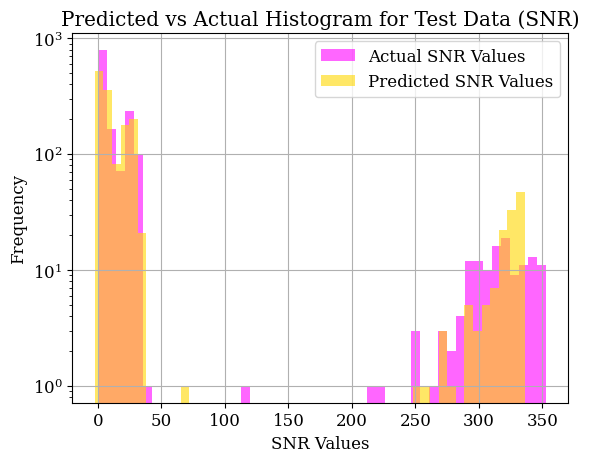

In [20]:
# Convert tensors back to numpy for plotting
test_inputs_np = test_inputs.numpy()
test_outputs_np = test_outputs.numpy()
test_targets_np = test_targets.numpy()

# Scale back to original values
test_outputs_np = test_outputs_np * target_std.numpy() + target_mean.numpy()
test_targets_np = test_targets_np * target_std.numpy() + target_mean.numpy()

# Plot predicted vs actual histogram test data SNR only
plt.hist(test_targets_np[:, 1], bins=50, alpha=0.6, label='Actual SNR Values', color = 'magenta')
plt.hist(test_outputs_np[:, 1], bins=50, alpha=0.6, label='Predicted SNR Values', color = 'gold')
plt.xlabel('SNR Values')
plt.ylabel('Frequency')
plt.title('Predicted vs Actual Histogram for Test Data (SNR)')
plt.legend()
plt.grid()
plt.yscale('log')

From inspection, the neural network was pretty accurate in predicting the corresponding SNR values from our test data.

### Next the amplitude predictions made from the NN

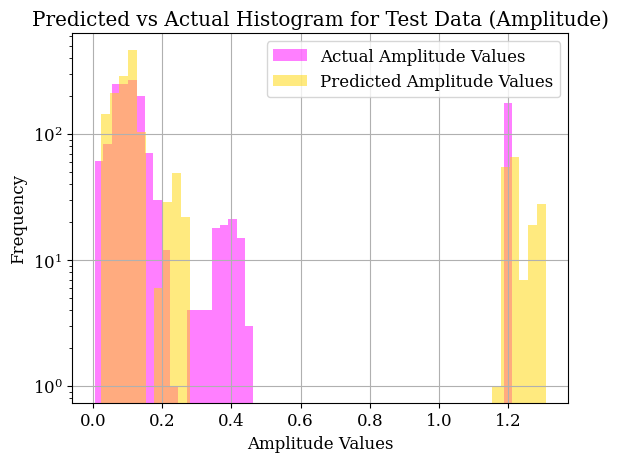

In [21]:
# Plot predicted vs actual histogram test data Amplitude only
plt.hist(test_targets_np[:, 2], bins=50, alpha=0.5, label='Actual Amplitude Values', color = 'magenta')
plt.hist(test_outputs_np[:, 2], bins=50, alpha=0.5, label='Predicted Amplitude Values', color = 'gold')
plt.xlabel('Amplitude Values')
plt.ylabel('Frequency')
plt.title('Predicted vs Actual Histogram for Test Data (Amplitude)')
plt.legend()
plt.grid()
plt.yscale('log')

From inspection of the histogram, it seems it wasn't able to acccurately predict the amplitude values from our test dataset. We can see the general shape is very similar but the frequency of amplitude values is shifted to the left.

### Conclusion on Neural Networks:
* We are easily able to train a model to transform SNR and Visability Amplitudes from uncalibrated to calibrated although the results are possibly not as great as other statistical methods like the one we did above.
* The neural network struggled because the mapping from uncalibrated to calibrated amplitude isn’t deterministic i.e. the calibration step depends on baseline dependent gain curves, it is more complex then look simply at visability amplitude.

# Overall Lab Conclusions / Key Takeaways

* **Uncalibrated vs Calibrated Visibility**  
  The uncalibrated amplitudes are heavily compressed toward zero, while the calibrated data span a much wider distribution. The KS test quantified this formally — the two distributions are statistically distinct (p ≈ 0), not just visually different.

* **Correlation Analysis Confirmed a Learnable Signal**  
  Pearson and Spearman correlation showed that uncalibrated and calibrated amplitudes are meaningfully correlated. This is the minimum condition for any model to work — without correlation, no amount of complexity could help.

* **Gain Structure is Baseline-Dependent**  
  The scatter plot colored by baseline pair revealed that each antenna pair has its own gain scaling. This explains why simple global transformations fail — and why the neural network needs baseline identity as a feature, not just raw amplitude.

* **Neural Network Learned Part of the Mapping**  
  A simple fully-connected network trained on uncalibrated features was able to predict calibrated SNR reasonably well, but amplitude predictions were less accurate. This is consistent with the physical reality: calibration depends on baseline-specific gain curves that can't be reconstructed from amplitude alone.

* **Main Insight: Calibration Is Not a Simple Function of Amplitude**  
  The uncalibrated → calibrated transformation is complex and baseline-dependent. Meaningful improvement would require incorporating additional features — antenna-specific gain information, atmospheric conditions, or per-baseline parameters — into the model.
